# 03 — Infraestrutura Digital e Gap Bancário

**Objetivo**: avaliar conectividade, infraestrutura digital e concorrência física dos bancos tradicionais.

**Inputs**: `data/processed/trusted_municipios_eda.parquet`.

**Outputs**: figuras de infraestrutura, gap bancário e matriz de quadrantes.

In [1]:
# Imports
import logging

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import PROCESSED_DATA_DIR
from src.utils.eda import (
    plot_boxplot_by_group,
    plot_distribution,
    save_figure,
    save_json,
)

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s"
)
logger = logging.getLogger(__name__)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [2]:
# Leitura
df = pd.read_parquet(PROCESSED_DATA_DIR / "trusted_municipios_eda.parquet")
logger.info("Linhas: %d, Colunas: %d", df.shape[0], df.shape[1])

2026-08-26 14:53:47,462 - INFO - Linhas: 5570, Colunas: 32


## 1. Municípios sem agência bancária

In [3]:
sem_agencia = df["flag_sem_agencia"].sum()
logger.info(
    "Municípios sem agência: %d (%.2f%%)",
    sem_agencia,
    sem_agencia / len(df) * 100,
)

2026-08-26 14:53:47,767 - INFO - Municípios sem agência: 2656 (47.68%)


## 2. Distribuição de infraestrutura digital e gap bancário

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-08-26 14:53:49,378 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/03_dist_banda_larga.png


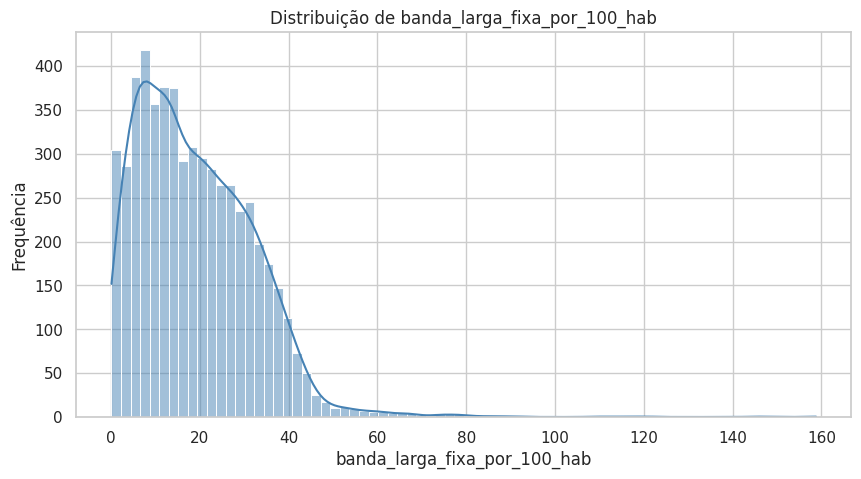

/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


2026-08-26 14:53:51,563 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/03_dist_agencias.png


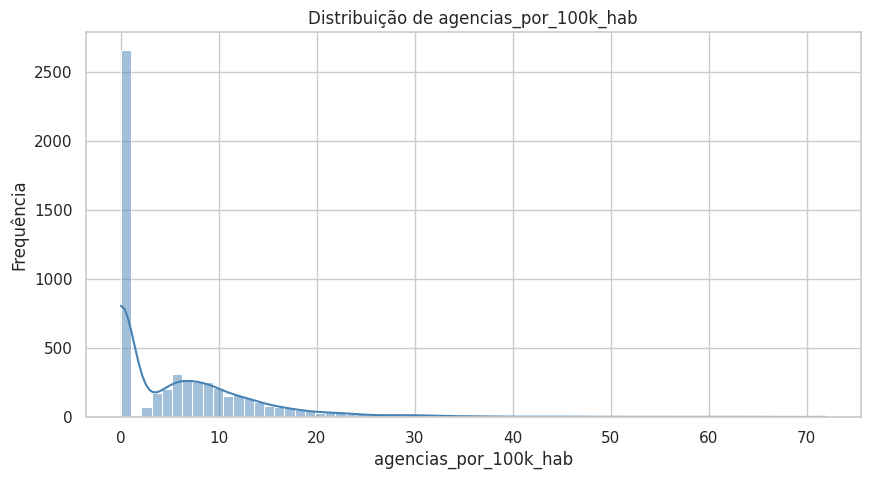

In [4]:
plot_distribution(
    df, "banda_larga_fixa_por_100_hab", filename="03_dist_banda_larga.png"
)
plt.show()

plot_distribution(
    df, "agencias_por_100k_hab", filename="03_dist_agencias.png"
)
plt.show()

## 3. Boxplots por região

2026-08-26 14:53:53,460 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/03_boxplot_banda_larga_fixa_por_100_hab_regiao.png


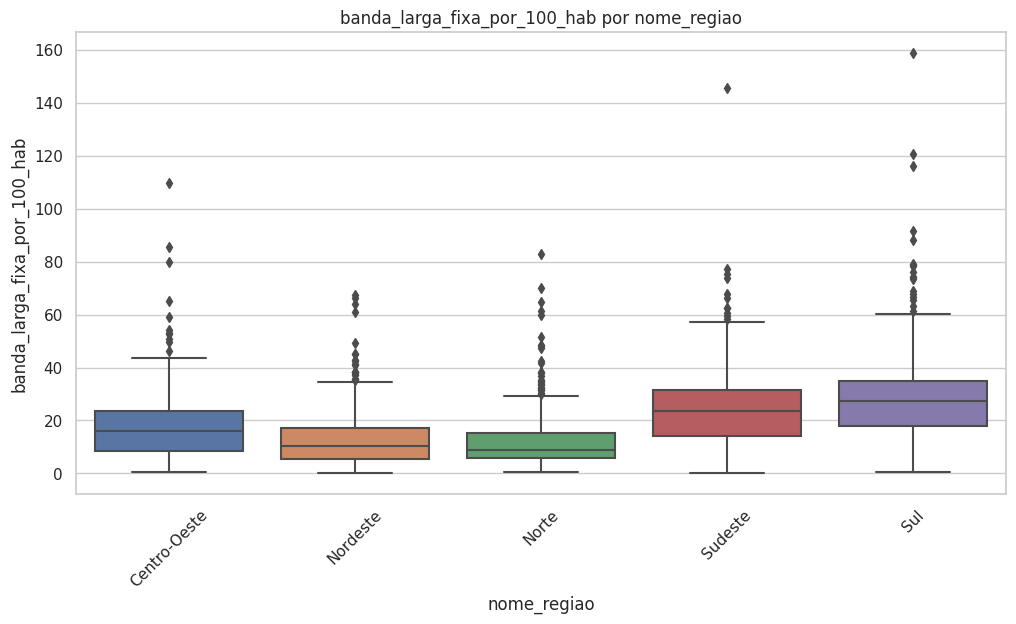

2026-08-26 14:53:55,036 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/03_boxplot_agencias_por_100k_hab_regiao.png


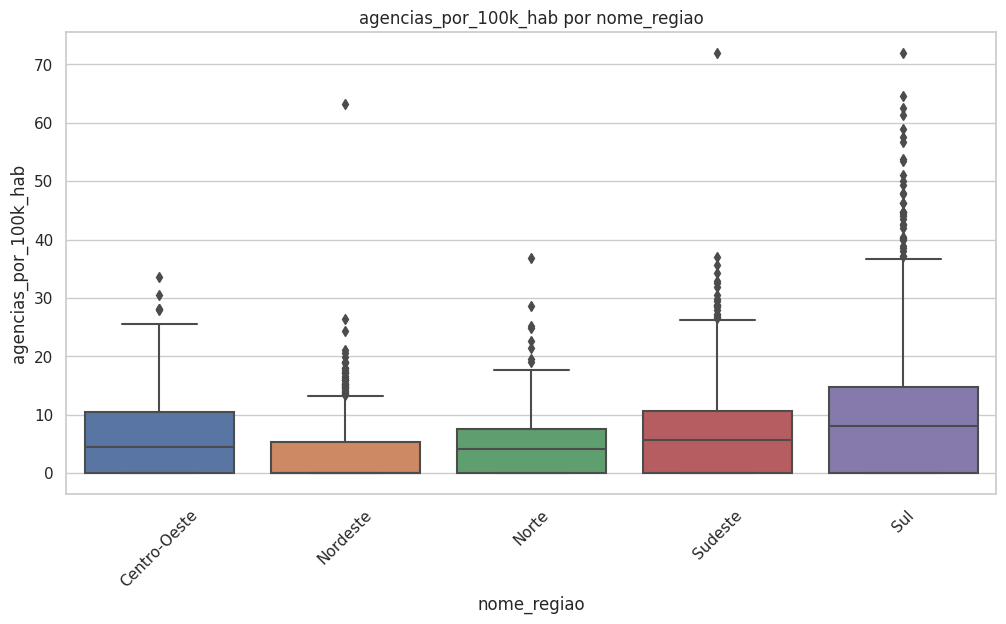

2026-08-26 14:53:56,448 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/03_boxplot_depositos_per_capita_regiao.png


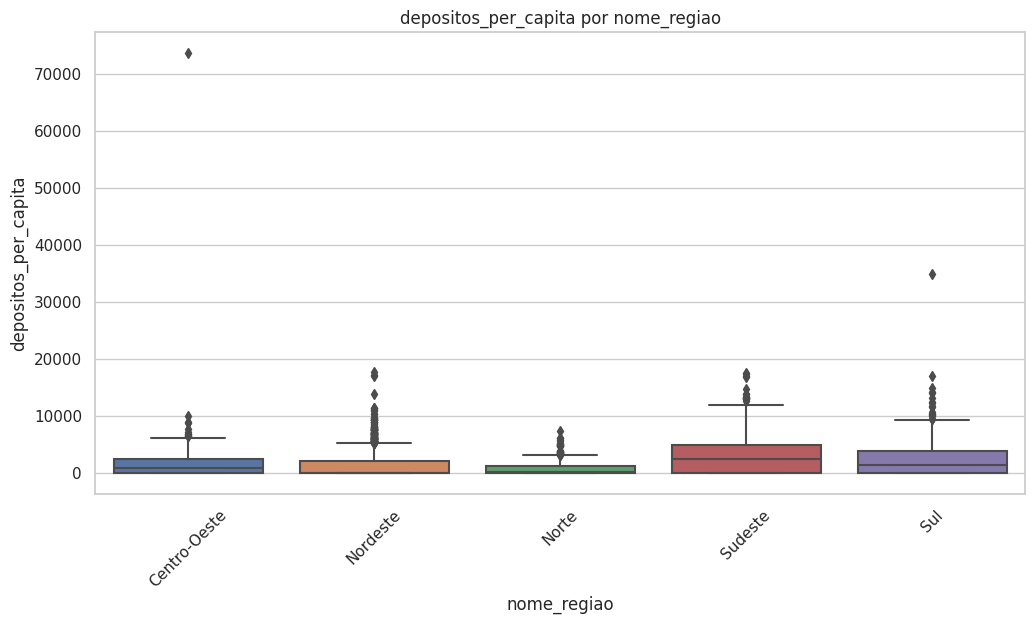

In [5]:
for col in ["banda_larga_fixa_por_100_hab", "agencias_por_100k_hab", "depositos_per_capita"]:
    plot_boxplot_by_group(df, col, "nome_regiao", filename=f"03_boxplot_{col}_regiao.png")
    plt.show()

## 4. Quadrantes: infraestrutura digital × gap bancário

In [6]:
mediana_banda = df["banda_larga_fixa_por_100_hab"].median()
mediana_agencias = df["agencias_por_100k_hab"].fillna(0).median()

df["quadrante"] = "desconectado"
df.loc[
    (df["banda_larga_fixa_por_100_hab"] >= mediana_banda)
    & (df["agencias_por_100k_hab"].fillna(0) < mediana_agencias),
    "quadrante",
] = "alto_potencial"
df.loc[
    (df["banda_larga_fixa_por_100_hab"] >= mediana_banda)
    & (df["agencias_por_100k_hab"].fillna(0) >= mediana_agencias),
    "quadrante",
] = "maduro_saturado"
df.loc[
    (df["banda_larga_fixa_por_100_hab"] < mediana_banda)
    & (df["agencias_por_100k_hab"].fillna(0) >= mediana_agencias),
    "quadrante",
] = "bancarizado_sem_infra"

logger.info("Distribuição dos quadrantes:\n%s", df["quadrante"].value_counts())

2026-08-26 14:53:57,058 - INFO - Distribuição dos quadrantes:
quadrante
maduro_saturado          1735
desconectado             1735
bancarizado_sem_infra    1050
alto_potencial           1050
Name: count, dtype: int64


2026-08-26 14:53:59,374 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/03_quadrantes_infra_gap.png


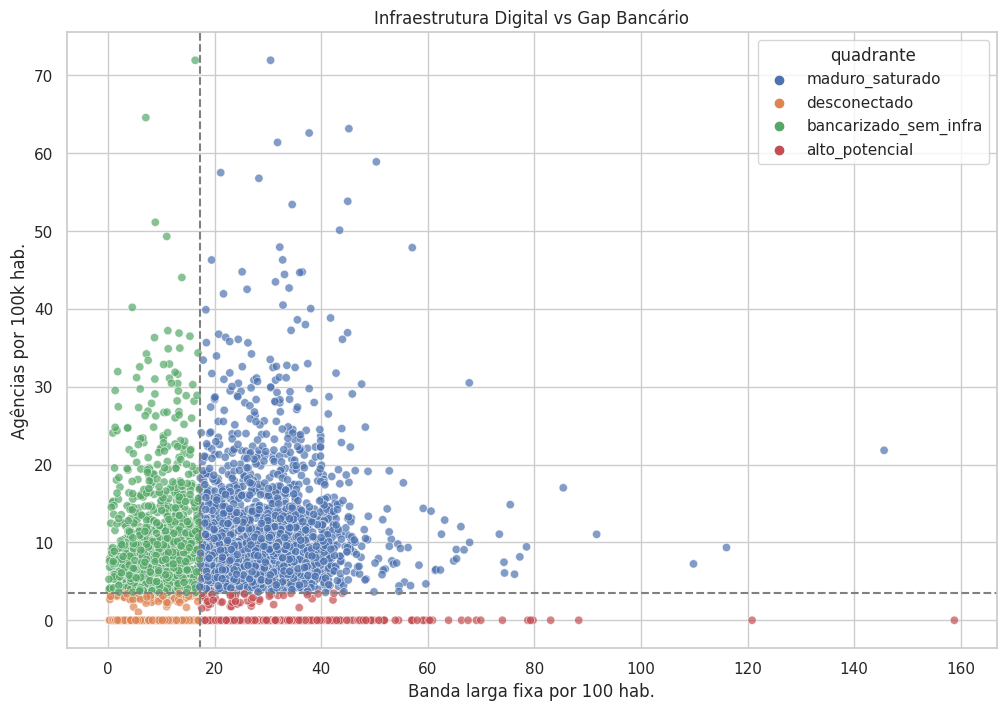

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x="banda_larga_fixa_por_100_hab",
    y="agencias_por_100k_hab",
    hue="quadrante",
    alpha=0.7,
    ax=ax,
)
ax.axvline(mediana_banda, color="gray", linestyle="--")
ax.axhline(mediana_agencias, color="gray", linestyle="--")
ax.set_title("Infraestrutura Digital vs Gap Bancário")
ax.set_xlabel("Banda larga fixa por 100 hab.")
ax.set_ylabel("Agências por 100k hab.")
save_figure(fig, "03_quadrantes_infra_gap.png")
plt.show()

## 5. Top estados com maior % de municípios sem agência

2026-08-26 14:54:02,998 - INFO - Figura salva em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/figures/03_pct_sem_agencia_uf.png


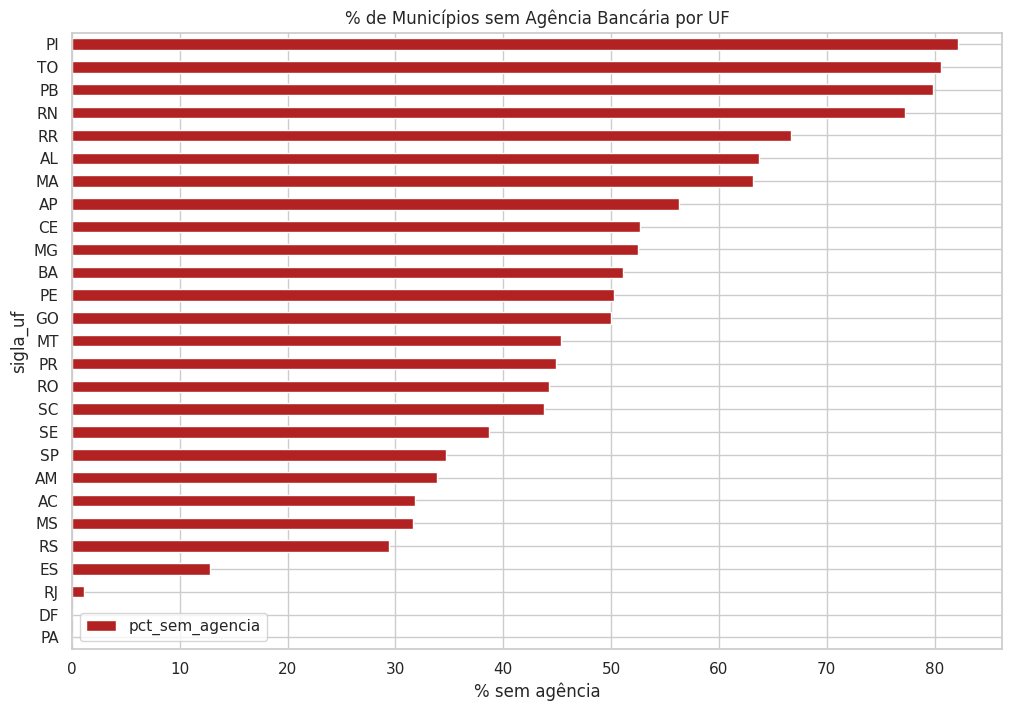

In [8]:
uf_sem_agencia = (
    df.groupby("sigla_uf")
    .agg(total=("id_municipio", "count"), sem_agencia=("flag_sem_agencia", "sum"))
    .reset_index()
)
uf_sem_agencia["pct_sem_agencia"] = (
    uf_sem_agencia["sem_agencia"] / uf_sem_agencia["total"] * 100
)
uf_sem_agencia = uf_sem_agencia.sort_values("pct_sem_agencia", ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
uf_sem_agencia.plot(
    x="sigla_uf", y="pct_sem_agencia", kind="barh", ax=ax, color="firebrick"
)
ax.set_title("% de Municípios sem Agência Bancária por UF")
ax.set_xlabel("% sem agência")
save_figure(fig, "03_pct_sem_agencia_uf.png")
plt.show()

In [9]:
report = {
    "municipios_sem_agencia": int(sem_agencia),
    "pct_municipios_sem_agencia": round(sem_agencia / len(df) * 100, 2),
    "distribuicao_quadrantes": df["quadrante"].value_counts().to_dict(),
    "top_uf_sem_agencia": uf_sem_agencia.tail(5).to_dict(orient="records"),
}
save_json(report, "03_infra_gap_bancario.json")

2026-08-26 14:54:04,410 - INFO - JSON salvo em /home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/03_infra_gap_bancario.json


PosixPath('/home/hbarboza/projects/tech/mba/heluvina_projeto_final_202602/data/processed/reports/03_infra_gap_bancario.json')

## Resumo Executivo

Este notebook gerou o relatório `03_infra_gap_bancario.json`. Abaixo segue um resumo legível dos principais resultados.

In [10]:
# Resumo legível do relatório gerado
import json
from pathlib import Path

report_path = Path.cwd().parents[1] / "data/processed/reports/03_infra_gap_bancario.json"
if report_path.exists():
    with open(report_path, "r", encoding="utf-8") as f:
        report = json.load(f)
    print(json.dumps(report, indent=2, ensure_ascii=False))
else:
    print("Relatório ainda não foi gerado.")

{
  "municipios_sem_agencia": 2656,
  "pct_municipios_sem_agencia": 47.68,
  "distribuicao_quadrantes": {
    "maduro_saturado": 1735,
    "desconectado": 1735,
    "bancarizado_sem_infra": 1050,
    "alto_potencial": 1050
  },
  "top_uf_sem_agencia": [
    {
      "sigla_uf": "RR",
      "total": 15,
      "sem_agencia": 10,
      "pct_sem_agencia": 66.66666666666666
    },
    {
      "sigla_uf": "RN",
      "total": 167,
      "sem_agencia": 129,
      "pct_sem_agencia": 77.24550898203593
    },
    {
      "sigla_uf": "PB",
      "total": 223,
      "sem_agencia": 178,
      "pct_sem_agencia": 79.82062780269058
    },
    {
      "sigla_uf": "TO",
      "total": 139,
      "sem_agencia": 112,
      "pct_sem_agencia": 80.57553956834532
    },
    {
      "sigla_uf": "PI",
      "total": 224,
      "sem_agencia": 184,
      "pct_sem_agencia": 82.14285714285714
    }
  ]
}
